# Intro of this notebook
This notebook has two core functions:
- Pull 3 years of data (2022-2024) from both SMARD and Openmeteo clients and inspect at it
- Sanity check: does the data make sense? e.g., solar should be zero at night, peak at midday in summer.


## Import Libraries

In [16]:
import requests
import pandas as pd
import sys
import os
sys.path.insert(0, os.path.abspath(".."))
from src.data.smard_client import fetch_solar_generation
from src.data.openmeteo_client import fetch_weather
import matplotlib.pyplot as plt


#### Fetch solar data of 3 years and check shape, dtypes and how it looks at the start and ending

In [7]:
df = fetch_solar_generation("2022-01-01", "2024-12-31")
print(f"The shape of Solar Generation data is: {df.shape}")
df.head()

The shape of Solar Generation data is: (26281, 2)


,time,solar_mw
0,2022-01-01 00:00:00+00:00,2.0
1,2022-01-01 01:00:00+00:00,2.0
2,2022-01-01 02:00:00+00:00,2.0
3,2022-01-01 03:00:00+00:00,2.0
4,2022-01-01 04:00:00+00:00,2.0


In [10]:
print(df.head(10))
print(df.tail())
df.dtypes

                       time  solar_mw
0 2022-01-01 00:00:00+00:00       2.0
1 2022-01-01 01:00:00+00:00       2.0
2 2022-01-01 02:00:00+00:00       2.0
3 2022-01-01 03:00:00+00:00       2.0
4 2022-01-01 04:00:00+00:00       2.0
5 2022-01-01 05:00:00+00:00       2.0
6 2022-01-01 06:00:00+00:00       2.0
7 2022-01-01 07:00:00+00:00     224.0
8 2022-01-01 08:00:00+00:00    1804.0
9 2022-01-01 09:00:00+00:00    4115.0
                           time  solar_mw
26276 2024-12-30 20:00:00+00:00      6.50
26277 2024-12-30 21:00:00+00:00      6.25
26278 2024-12-30 22:00:00+00:00      6.50
26279 2024-12-30 23:00:00+00:00      7.25
26280 2024-12-31 00:00:00+00:00      6.00


time        datetime64[ns, UTC]
solar_mw                float64
dtype: object

#### Fetch Wather data and check shape and structure

In [12]:
df_weather = fetch_weather(51.2, 10.4, "2022-01-01", "2024-12-31")
print(df_weather.shape)
df_weather.head()

(26304, 5)


,time,shortwave_radiation,cloud_cover,temperature_2m,wind_speed_10m
0,2022-01-01 00:00:00+00:00,0.0,100,10.5,16.8
1,2022-01-01 01:00:00+00:00,0.0,100,10.6,17.2
2,2022-01-01 02:00:00+00:00,0.0,100,10.4,17.8
3,2022-01-01 03:00:00+00:00,0.0,96,10.5,19.5
4,2022-01-01 04:00:00+00:00,0.0,100,9.7,15.9


In [13]:
df["solar_mw"].describe()

count    26281.000000
mean      6634.862191
std      10186.022855
min          1.000000
25%          4.000000
50%        191.750000
75%      10543.000000
max      46897.500000
Name: solar_mw, dtype: float64

##### investigate nulls and zeros (min should be 0 at night); a bit suspecious

In [14]:
print(df["solar_mw"].isna().sum())       # how many nulls?
print((df["solar_mw"] == 0).sum())       # how many true zeros?

0
0


##### does the `time` column cover full 24h days, or only daytime hours?

In [15]:
df["hour"] = df["time"].dt.hour
print(df.groupby("hour")["solar_mw"].count())


hour
0     1096
1     1095
2     1095
3     1095
4     1095
5     1095
6     1095
7     1095
8     1095
9     1095
10    1095
11    1095
12    1095
13    1095
14    1095
15    1095
16    1095
17    1095
18    1095
19    1095
20    1095
21    1095
22    1095
23    1095
Name: solar_mw, dtype: int64


> [!Info] Initial Observation
> "SMARD encodes nighttime as ~2 MW floor (not true zero). 23 missing rows at tail (publication lag). Weather data: 26,304 rows, all 24h present."

##### Check peak summer stat by plotting it to confirm normal distribution

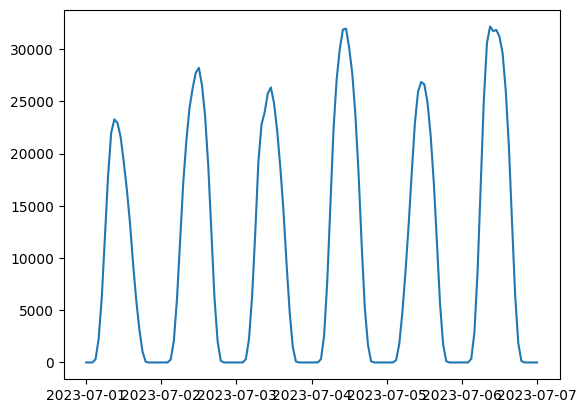

In [17]:
mask = (df["time"] >= "2023-07-01") & (df["time"] <= "2023-07-07")
week = df.loc[mask]
plt.plot(week["time"], week["solar_mw"])
plt.show()